In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
from tqdm.auto import tqdm
sys.path.insert(0, os.path.abspath("../fsrs-optimizer/src/fsrs_optimizer/"))
import numpy as np
from sklearn.model_selection import train_test_split

tqdm.pandas()

/home/luc/Programming/forks/fatigue-graph/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Review count: User id
# Median: 8798
# Most: 6810

USER_ID = 324
df = pd.read_parquet(
    "../anki-revlogs-10k/revlogs", filters=[("user_id", "=", USER_ID), ("rating", "in", [1, 2, 3, 4])], columns=["card_id", "day_offset", "rating", "elapsed_days", "duration"] 
)
df.size

129775

In [4]:
df_filtered = df[(df["elapsed_days"] > 0)]

In [5]:
groups = df_filtered.groupby("rating")["duration"].median()

df_filtered["review_average"] = df_filtered["rating"].map(groups)

current_residual = df_filtered.groupby("rating").apply(lambda x: abs(x["duration"] - x["review_average"]).mean())

current_residual, groups

/tmp/ipykernel_102381/2144162587.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["review_average"] = df_filtered["rating"].map(groups)
/tmp/ipykernel_102381/2144162587.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  current_residual = df_filtered.groupby("rating").apply(lambda x: abs(x["duration"] - x["review_average"]).mean())


(rating
 1    4532.963761
 2    3343.827811
 3    2504.271120
 4    2152.288889
 dtype: float64,
 rating
 1    6705.0
 2    6000.0
 3    4445.5
 4    4494.0
 Name: duration, dtype: float64)

In [6]:
day_accuracies = df_filtered.groupby("day_offset")[["duration", "review_average"]]
unique_days = df_filtered["day_offset"].unique()

train_days, test_days = train_test_split(unique_days)

train_df = df_filtered[df_filtered["day_offset"].isin(train_days)]
test_df = df_filtered[df_filtered["day_offset"].isin(test_days)]

train_groups = train_df.groupby("day_offset")[["duration", "review_average"]]
test_groups = test_df.groupby("day_offset")[["duration", "review_average"]]

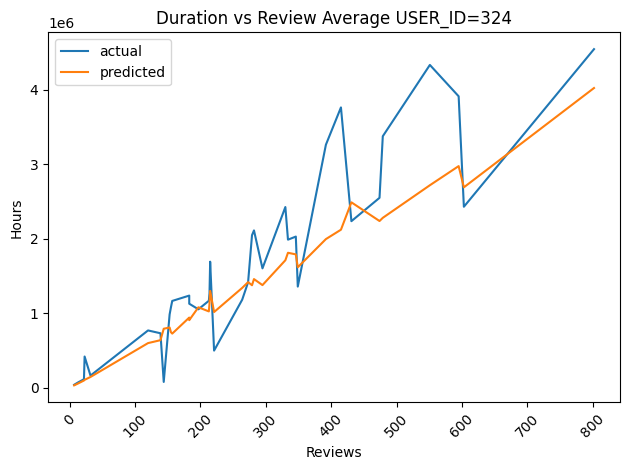

In [7]:
import matplotlib.pyplot as plt

def counts_sums(groups):
    # Compute count and sum
    counts = groups.count()
    sums = groups.sum()

    # Sort by count of 'duration' (or 'review_average' – whichever makes sense)
    sorted_indices = counts["duration"].sort_values().index

    # Reorder both sums and counts to match
    counts = counts.loc[sorted_indices]
    sums = sums.loc[sorted_indices]
    return counts, sums

counts, sums = counts_sums(day_accuracies)

# Plot
plt.plot(counts["duration"], sums["duration"], label="actual")
plt.plot(counts["review_average"], sums["review_average"], label="predicted")

plt.xlabel("Reviews")
plt.ylabel("Hours")
plt.title(f"Duration vs Review Average {USER_ID=}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()


# Find trend

An idea where the days with higher duration may have less or more inaccuracy but there doesn't seem to be a correlation

array([-5.30881345e-04,  1.41214165e+00])

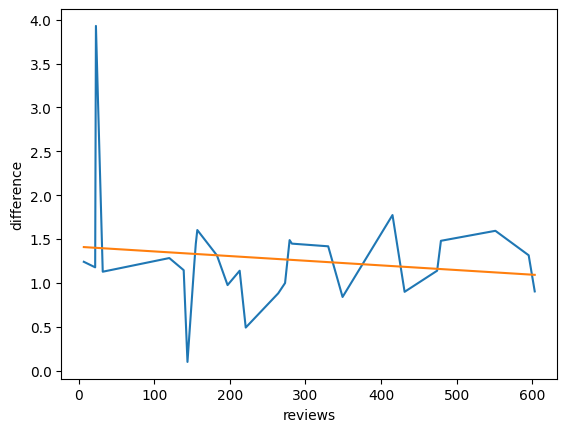

In [8]:
import numpy as np

counts, sums = counts_sums(train_groups)

difference = sums["duration"] / sums["review_average"]
plt.plot(counts["review_average"], difference, label="error")
c = np.polyfit(counts["review_average"], difference, 1)
adjustment = np.polyval(c, counts["review_average"])
plt.plot(counts["review_average"], adjustment, label="adjustment")
plt.xlabel("reviews")
plt.ylabel("difference")
c

# Rating medians

('Mean error', 'before', np.float64(438202.5740740741))

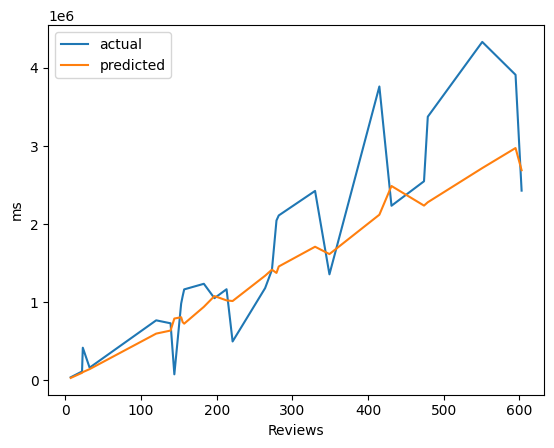

In [9]:
plt.plot(counts["duration"], sums["duration"], label="actual")
plt.plot(counts["review_average"], sums["review_average"], label="predicted")

plt.xlabel("Reviews")
plt.ylabel("ms")

plt.legend()
"Mean error", "before", abs(sums["duration"] - sums["review_average"]).mean()

# Calculated multiplier

If you take the average difference between the predicted values and the actual values on a day to day basis, you can use that as a multiplier to make the timings more accurate.

(np.float64(1.2727164775448605),
 'Mean error',
 'before',
 np.float64(354862.94444444444),
 'after',
 np.float64(249996.72384203286))

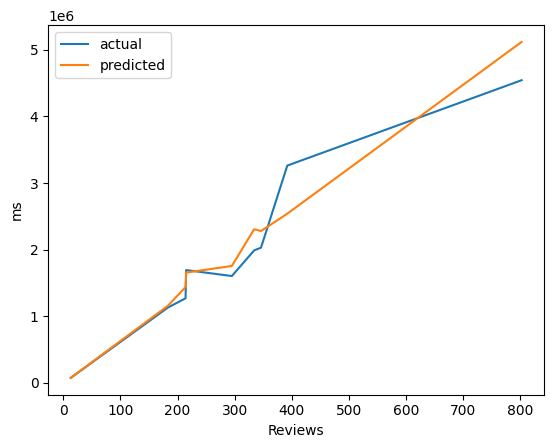

In [ ]:
counts, sums = counts_sums(train_groups)
loss_aversion_mean = (sums["duration"] / sums["review_average"]).mean()
loss_aversion_mean_squared = (sums["duration"] / sums["review_average"]).mean()

counts, sums = counts_sums(test_groups)

plt.plot(counts["duration"], sums["duration"], label="actual")
plt.plot(counts["review_average"], sums["review_average"] * loss_aversion_mean, label="predicted")
plt.xlabel("Reviews")
plt.ylabel("ms")
plt.legend()

loss_aversion_mean, "Mean error", "before", abs(sums["duration"] - sums["review_average"]).mean(), "after", (abs(sums["duration"] - (sums["review_average"]) * loss_aversion_mean)).mean()

# Rating medians * review adjustment

('Mean error',
 'before',
 np.float64(354862.94444444444),
 'after',
 np.float64(250983.82384566884))

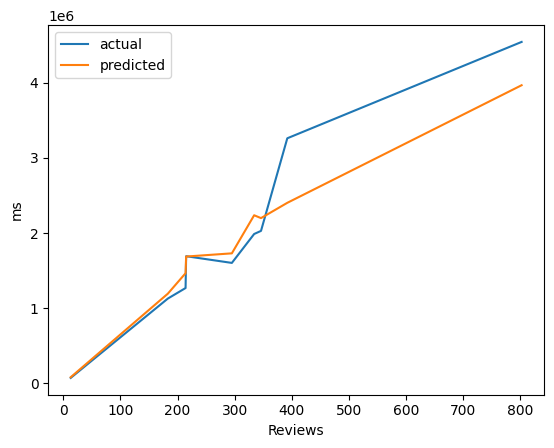

In [13]:

counts, sums = counts_sums(test_groups)
adjustment = np.polyval(c, counts["review_average"])

plt.plot(counts["duration"], sums["duration"], label="actual")
plt.plot(counts["review_average"], sums["review_average"] * adjustment, label="predicted")
plt.xlabel("Reviews")
plt.ylabel("ms")
plt.legend()

"Mean error", "before", abs(sums["duration"] - sums["review_average"]).mean(), "after", (abs(sums["duration"] - (sums["review_average"]) * adjustment)).mean()

# Pretty much ignore this I think

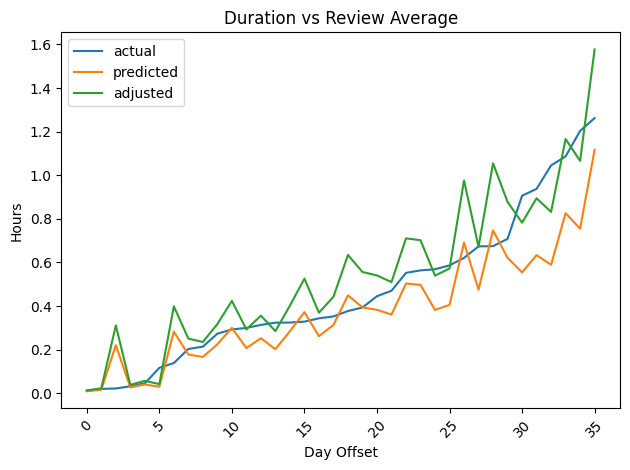

In [ ]:
import matplotlib.pyplot as plt

# Group, sample, and prepare data
day_accuracies = df_filtered.groupby("day_offset")[["duration", "review_average"]].sum()
day_accuracies.sort_values("duration", inplace=True)
day_accuracies.reset_index(inplace=True)

# Optionally convert units now
day_accuracies["duration"] /= (1000 * 60 * 60)        # convert to hours
day_accuracies["review_average"] /= (1000 * 60 * 60)  # convert to hours
adjustment = np.polyval(c, day_accuracies["review_average"])

plt.plot(day_accuracies.index, day_accuracies["duration"], label="actual")
plt.plot(day_accuracies.index, day_accuracies["review_average"], label="predicted")
plt.plot(day_accuracies.index, day_accuracies["review_average"] * adjustment, label="adjusted")

plt.xlabel("Day (Sorted by total duration))")
plt.ylabel("Hours")
plt.title("Duration vs Review Average")
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()
